<a href="https://colab.research.google.com/github/Memucan-ctrl/codveda-ml-internship/blob/main/level2_task2_decision_tree/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Level 2 — Task 2: Decision Tree Classifier

Dataset: Iris (sklearn)
Model: DecisionTreeClassifier, tuned via GridSearchCV (max_depth, ccp_alpha)
Results: Accuracy = 0.933, F1 macro = 0.933
Insight: Setosa is linearly separable on petal length; versicolor/virginica overlap on petal width.

Unpruned acc: 0.9333333333333333
Best params: {'ccp_alpha': 0.0, 'max_depth': 4}
Accuracy : 0.9333333333333333
F1 macro : 0.9333333333333332
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



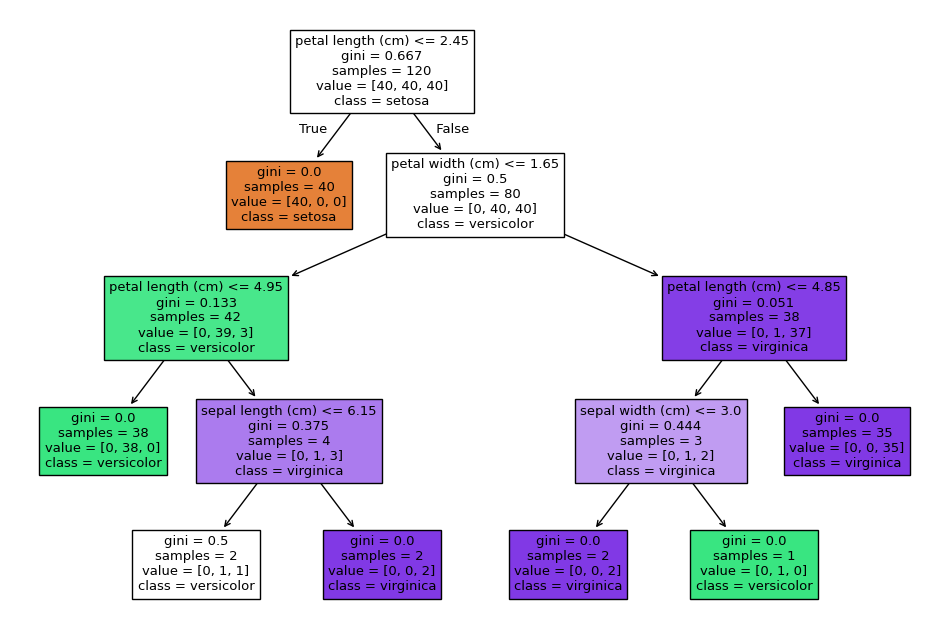

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# Unpruned tree
tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print('Unpruned acc:', accuracy_score(y_test, tree.predict(X_test)))

# Prune via GridSearch on max_depth + ccp_alpha
param_grid = {'max_depth': [2, 3, 4, 5, None],
              'ccp_alpha': [0.0, 0.005, 0.01, 0.02]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                  param_grid, cv=5, scoring='f1_macro').fit(X_train, y_train)
best = gs.best_estimator_
print('Best params:', gs.best_params_)

y_pred = best.predict(X_test)
print('Accuracy :', accuracy_score(y_test, y_pred))
print('F1 macro :', f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))

# Visualize
fig, ax = plt.subplots(figsize=(12, 8))
plot_tree(best, feature_names=load_iris().feature_names,
          class_names=load_iris().target_names, filled=True, ax=ax)
plt.show()